# Notebook 22 — Tandem Inverse Design (A2 CNN + B4)

**Goal**: Train an inverse network that maps a **1000-point target absorption spectrum → 20 design parameters**,
using the pre-trained CNN forward surrogate to resolve non-uniqueness.

| Aspect | Detail |
|--------|--------|
| **Forward surrogate** | A2 CNN (loaded from `forward_surrogate_cnn.pth`, frozen) |
| **Inverse architecture** | 1D-CNN Spectrum Encoder → MLP decoder → 20 params |
| **Loss** | Spectral MSE through frozen surrogate (primary) + Parameter MSE (secondary, 0.1×) |
| **Key idea** | The "tandem trick" — training the inverse net through the frozen forward net resolves the many-to-one mapping problem |
| **Inference** | Single forward pass — fastest of all inverse methods |

In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================
import sys, os, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath('../src'))
from Theoretical_model import calculate_acoustic_properties
from physics_guided_CD_FiLM import PARAM_RANGES, validate_and_clip_parameters, PARAM_RANGES

# ---------- Device ----------
assert torch.cuda.is_available(), 'CUDA required'
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f'Device: {torch.cuda.get_device_name()}')

# ---------- Reproducibility ----------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------- Paths ----------
DATA_PATH        = '../data/Data/lhs_data_full_spectrum.npz'
MODEL_DIR        = '../models'
SURROGATE_PATH   = os.path.join(MODEL_DIR, 'forward_surrogate_cnn.pth')
SCALER_PATH      = os.path.join(MODEL_DIR, 'forward_surrogate_cnn_scaler.pkl')
INVERSE_PATH     = os.path.join(MODEL_DIR, 'inverse_tandem_a2.pth')
INV_SCALER_PATH  = os.path.join(MODEL_DIR, 'inverse_tandem_a2_scaler.pkl')

# ---------- Hyper-parameters ----------
BATCH_SIZE   = 1024
EPOCHS       = 100
LR_INIT      = 1e-3
LR_MIN       = 1e-6
HIDDEN_DIM   = 512
NUM_PARAMS   = 20
NUM_FREQ     = 1000
LAMBDA_PARAM = 0.1      # weight for parameter MSE term

PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']

print('\n✓ Imports & config ready')

Device: NVIDIA GeForce RTX 2060 SUPER

✓ Imports & config ready


## Load Data

In [2]:
# ============================================================
# Cell 2 — Load Data & Split (same split as Notebook 18)
# ============================================================
print('Loading NPZ …')
t0 = time.time()
raw = np.load(DATA_PATH)
params_all  = raw['params'].astype(np.float32)
spectra_all = raw['spectra'].astype(np.float32)
frequencies = raw['frequencies']
print(f'  Loaded in {time.time()-t0:.1f}s')

# Same split as Notebook 18 (random_state=42)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    params_all, spectra_all, test_size=0.2, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=SEED)

print(f'  Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

# Normalise parameters
scaler_x = MinMaxScaler()
X_train_n = scaler_x.fit_transform(X_train)
X_val_n   = scaler_x.transform(X_val)
X_test_n  = scaler_x.transform(X_test)

print('✓ Data ready')

Loading NPZ …
  Loaded in 54.2s
  Train: 800,000  Val: 100,000  Test: 100,000
✓ Data ready


In [3]:
# ============================================================
# Cell 3 — DataLoaders (input=spectra, target=normalised params)
# ============================================================
def make_loader(spectra, params_norm, batch_size, shuffle=True):
    """For inverse model: input=spectra, target=normalised params."""
    ds = TensorDataset(torch.tensor(spectra, dtype=torch.float32),
                       torch.tensor(params_norm, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

train_loader = make_loader(Y_train, X_train_n, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(Y_val,   X_val_n,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(Y_test,  X_test_n,  BATCH_SIZE, shuffle=False)

print(f'✓ DataLoaders — {len(train_loader)} train batches')

✓ DataLoaders — 782 train batches


## Load Pre-Trained Forward Surrogate (A2 CNN)

The forward surrogate maps **20 normalised params → 1000-point spectrum**. It is **frozen** during training.
Gradients flow *through* it to train the inverse network.

In [4]:
# ============================================================
# Cell 4 — Load Forward Surrogate (A2 CNN)
# ============================================================
class ForwardSurrogateCNN(nn.Module):
    """Must match architecture from Notebook 18."""
    def __init__(self, in_dim=20, out_dim=1000):
        super().__init__()
        self.in_dim = in_dim; self.out_dim = out_dim
        self.stem = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(256, 128*32), nn.BatchNorm1d(128*32), nn.LeakyReLU(0.01, inplace=True))
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 4, 2, 1), nn.BatchNorm1d(64), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.BatchNorm1d(32), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.BatchNorm1d(16), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(16, 8, 4, 2, 1), nn.BatchNorm1d(8), nn.LeakyReLU(0.01, inplace=True))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(8*512, 1024),
            nn.LeakyReLU(0.01, inplace=True), nn.Linear(1024, out_dim), nn.Sigmoid())

    def forward(self, x):
        h = self.stem(x); h = h.view(-1, 128, 32); h = self.decoder(h); return self.head(h)


# Load checkpoint
ckpt = torch.load(SURROGATE_PATH, map_location=device, weights_only=False)
arch = ckpt['architecture']

surrogate = ForwardSurrogateCNN(
    in_dim=arch['in_dim'], out_dim=arch['out_dim']
).to(device)
surrogate.load_state_dict(ckpt['model_state_dict'])
surrogate.eval()

# Freeze all parameters — gradients flow through but weights don't update
for p in surrogate.parameters():
    p.requires_grad = False

print(f'✓ Forward surrogate loaded from {SURROGATE_PATH}')
print(f'  Test spectral MSE (from training): {ckpt["test_metrics"]["spectral_mse"]:.6e}')

✓ Forward surrogate loaded from ../models\forward_surrogate_cnn.pth
  Test spectral MSE (from training): 3.898822e-05


## Inverse Model Architecture

```
Spectrum (1000)
  │
  ├─ SpectrumEncoder (1D-CNN)
  │    Conv1d(1,32,k=7,s=2) → BN → LeakyReLU    → (32, 500)
  │    Conv1d(32,64,k=5,s=2) → BN → LeakyReLU   → (64, 249)
  │    Conv1d(64,128,k=3,s=2) → BN → LeakyReLU  → (128, 124)
  │    AdaptiveAvgPool1d(1)                       → (128,)
  │    Linear(128, 512) → LeakyReLU               → (512,)
  │
  ├─ InverseDecoder (MLP)
  │    Linear(512, 256) → BN → LeakyReLU
  │    Linear(256, 128) → BN → LeakyReLU
  │    Linear(128, 20) → Sigmoid
  │
  └─ Output: 20 normalised design parameters
```

In [5]:
# ============================================================
# Cell 5 — Inverse Model Definition
# ============================================================
class SpectrumEncoder(nn.Module):
    """1D-CNN encoder: 1000-point spectrum → 512-dim embedding."""
    def __init__(self, embed_dim=512):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32,  kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01, inplace=True),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01, inplace=True),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01, inplace=True),

            nn.AdaptiveAvgPool1d(1),   # (B, 128, 1)
        )
        self.fc = nn.Sequential(
            nn.Linear(128, embed_dim),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, spectrum):
        # spectrum: (B, 1000)
        x = spectrum.unsqueeze(1)    # (B, 1, 1000)
        x = self.conv(x)             # (B, 128, 1)
        x = x.squeeze(-1)            # (B, 128)
        return self.fc(x)            # (B, 512)


class TandemInverseNet(nn.Module):
    """Spectrum → 20 design parameters via tandem strategy."""
    def __init__(self, embed_dim=512, num_params=20):
        super().__init__()
        self.encoder = SpectrumEncoder(embed_dim=embed_dim)
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(0.05),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01, inplace=True),

            nn.Linear(128, num_params),
            nn.Sigmoid(),      # output ∈ [0,1] (normalised params)
        )

    def forward(self, spectrum):
        emb = self.encoder(spectrum)
        return self.decoder(emb)


inverse_model = TandemInverseNet(embed_dim=HIDDEN_DIM, num_params=NUM_PARAMS).to(device)
total_params = sum(p.numel() for p in inverse_model.parameters())
print(f'✓ TandemInverseNet — {total_params:,} parameters')
print(inverse_model)

✓ TandemInverseNet — 269,332 parameters
TandemInverseNet(
  (encoder): SpectrumEncoder(
    (conv): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01, inplace=True)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
      (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01, inplace=True)
      (9): AdaptiveAvgPool1d(output_size=1)
    )
    (fc): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): LeakyReLU(negative_slope=0.01, inplace=True)
    )
  )
  (decoder): Sequential(
    (0

## Loss Function & Training

**Tandem loss:**
$$L = L_{\text{spectral}} + \lambda \cdot L_{\text{param}}$$

- $L_{\text{spectral}} = \text{MSE}(\text{surrogate}(\hat{\theta}), \alpha_{\text{target}})$ — ensures predicted params *produce* the target spectrum
- $L_{\text{param}} = \text{MSE}(\hat{\theta}_n, \theta_n)$ — weak regularisation toward ground-truth params
- $\lambda = 0.1$ — the spectral loss dominates, allowing non-unique parameter solutions

In [6]:
# ============================================================
# Cell 6 — Loss, Optimiser, Scheduler
# ============================================================
def build_freq_weights(num_freq=NUM_FREQ, low_cutoff=400, low_weight=2.0, device='cpu'):
    w = torch.ones(num_freq, device=device)
    w[:low_cutoff] = low_weight
    w = w / w.mean()
    return w

freq_weights = build_freq_weights(device=device)

def tandem_loss(pred_params_norm, target_spectrum, true_params_norm,
               surrogate_fn=surrogate, weights=freq_weights, lam=LAMBDA_PARAM):
    """
    Tandem loss: spectral MSE (through surrogate) + parameter MSE.
    """
    # Spectral loss: predicted params → surrogate → spectrum → MSE with target
    pred_spectrum = surrogate_fn(pred_params_norm)
    diff_sq = (pred_spectrum - target_spectrum) ** 2
    L_spectral = (diff_sq * weights).mean()

    # Parameter loss: weak regularisation
    L_param = nn.functional.mse_loss(pred_params_norm, true_params_norm)

    return L_spectral + lam * L_param, L_spectral.item(), L_param.item()


optimizer = optim.Adam(inverse_model.parameters(), lr=LR_INIT, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

print(f'✓ Tandem loss (λ_param={LAMBDA_PARAM}), Adam lr={LR_INIT}, CosineAnnealing')

✓ Tandem loss (λ_param=0.1), Adam lr=0.001, CosineAnnealing


In [7]:
# ============================================================
# Cell 7 — Training Loop
# ============================================================
train_losses = []
val_losses   = []
train_spec_losses = []
val_spec_losses   = []
best_val = float('inf')
best_state = None

print(f'Training {EPOCHS} epochs …\n')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ---------- Train ----------
    inverse_model.train()
    surrogate.eval()  # always eval mode (frozen)
    ep_loss, ep_spec, ep_param = 0.0, 0.0, 0.0

    for spec_b, params_b in train_loader:
        spec_b   = spec_b.to(device)
        params_b = params_b.to(device)

        pred_params = inverse_model(spec_b)
        loss, l_spec, l_param = tandem_loss(pred_params, spec_b, params_b)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(inverse_model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = spec_b.size(0)
        ep_loss  += loss.item() * bs
        ep_spec  += l_spec * bs
        ep_param += l_param * bs

    n_train = len(train_loader.dataset)
    train_losses.append(ep_loss / n_train)
    train_spec_losses.append(ep_spec / n_train)

    # ---------- Validate ----------
    inverse_model.eval()
    v_loss, v_spec = 0.0, 0.0
    with torch.no_grad():
        for spec_b, params_b in val_loader:
            spec_b   = spec_b.to(device)
            params_b = params_b.to(device)
            pred_params = inverse_model(spec_b)
            loss, l_spec, _ = tandem_loss(pred_params, spec_b, params_b)
            v_loss += loss.item() * spec_b.size(0)
            v_spec += l_spec * spec_b.size(0)

    n_val = len(val_loader.dataset)
    val_losses.append(v_loss / n_val)
    val_spec_losses.append(v_spec / n_val)

    scheduler.step()

    # ---------- Checkpoint ----------
    if val_losses[-1] < best_val:
        best_val   = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in inverse_model.state_dict().items()}
        tag = ' ★'
    else:
        tag = ''

    if epoch % 10 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch:3d}/{EPOCHS}  '
              f'train {train_losses[-1]:.6f}  val {val_losses[-1]:.6f}  '
              f'spec {val_spec_losses[-1]:.6f}  lr {lr_now:.2e}{tag}')

elapsed = time.time() - t_start
print(f'\n✓ Training complete in {elapsed/60:.1f} min — best val loss = {best_val:.6f}')

inverse_model.load_state_dict(best_state)
inverse_model.to(device)
print('  Best checkpoint restored')

Training 100 epochs …

  Epoch   1/100  train 0.007896  val 0.010869  spec 0.003289  lr 1.00e-03 ★
  Epoch  10/100  train 0.007236  val 0.034382  spec 0.024242  lr 9.76e-04
  Epoch  20/100  train 0.007180  val 0.013824  spec 0.004514  lr 9.05e-04
  Epoch  30/100  train 0.007142  val 0.027018  spec 0.017018  lr 7.94e-04
  Epoch  40/100  train 0.007114  val 0.008366  spec 0.000484  lr 6.55e-04
  Epoch  50/100  train 0.007086  val 0.009101  spec 0.001373  lr 5.01e-04
  Epoch  60/100  train 0.007053  val 0.019176  spec 0.005440  lr 3.46e-04
  Epoch  70/100  train 0.007029  val 0.007572  spec 0.000154  lr 2.07e-04
  Epoch  80/100  train 0.007001  val 0.017263  spec 0.004133  lr 9.64e-05
  Epoch  90/100  train 0.006985  val 0.007278  spec 0.000058  lr 2.54e-05
  Epoch 100/100  train 0.006975  val 0.006935  spec 0.000028  lr 1.00e-06 ★

✓ Training complete in 68.1 min — best val loss = 0.006935
  Best checkpoint restored


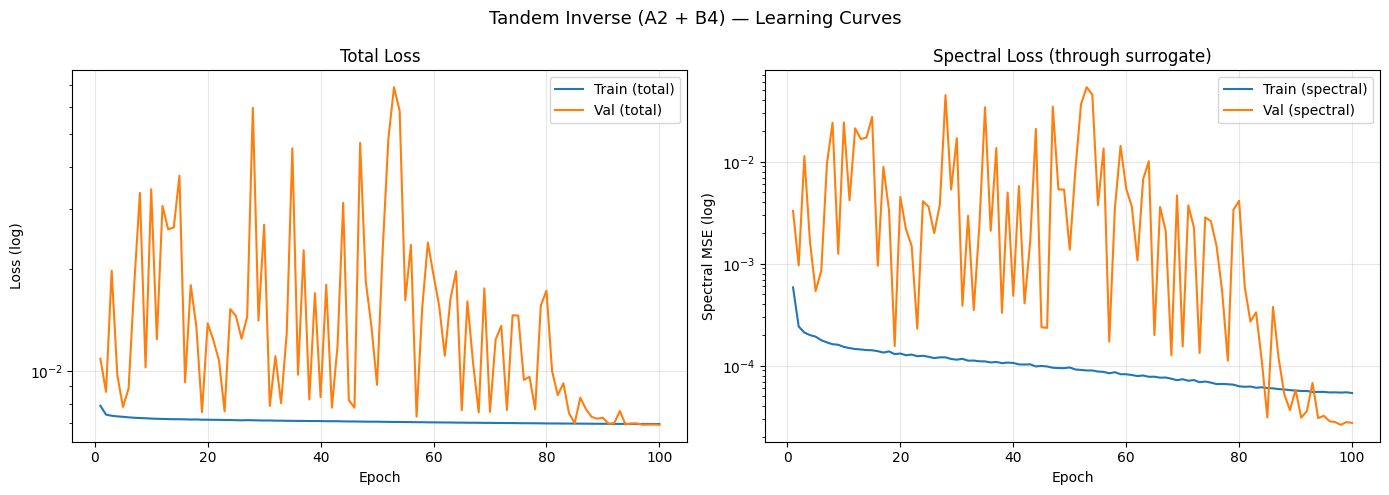

In [8]:
# ============================================================
# Cell 8 — Learning Curves
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(range(1, EPOCHS+1), train_losses, label='Train (total)')
ax1.semilogy(range(1, EPOCHS+1), val_losses,   label='Val (total)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss (log)')
ax1.set_title('Total Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(range(1, EPOCHS+1), train_spec_losses, label='Train (spectral)')
ax2.semilogy(range(1, EPOCHS+1), val_spec_losses,   label='Val (spectral)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Spectral MSE (log)')
ax2.set_title('Spectral Loss (through surrogate)'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Tandem Inverse (A2 + B4) — Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

## Test-Set Evaluation

In [9]:
# ============================================================
# Cell 9 — Test-Set Metrics (via surrogate)
# ============================================================
inverse_model.eval()
surrogate.eval()

all_pred_params_n = []
all_true_params_n = []
all_target_spec   = []
all_recon_spec    = []

with torch.no_grad():
    for spec_b, params_b in test_loader:
        spec_b = spec_b.to(device)
        pred_p = inverse_model(spec_b)           # (B, 20) normalised
        recon  = surrogate(pred_p)               # (B, 1000)

        all_pred_params_n.append(pred_p.cpu().numpy())
        all_true_params_n.append(params_b.numpy())
        all_target_spec.append(spec_b.cpu().numpy())
        all_recon_spec.append(recon.cpu().numpy())

pred_params_n = np.concatenate(all_pred_params_n)   # (N, 20)
true_params_n = np.concatenate(all_true_params_n)
target_spec   = np.concatenate(all_target_spec)     # (N, 1000)
recon_spec    = np.concatenate(all_recon_spec)

# Un-normalise predictions
pred_params_raw = scaler_x.inverse_transform(pred_params_n)
true_params_raw = scaler_x.inverse_transform(true_params_n)

# Metrics
spec_mse_per_sample = np.mean((recon_spec - target_spec)**2, axis=1)
overall_spec_mse    = spec_mse_per_sample.mean()
param_mse           = np.mean((pred_params_n - true_params_n)**2)

avg_target = target_spec.mean(axis=1)
avg_recon  = recon_spec.mean(axis=1)
avg_abs_err = np.mean(np.abs(avg_target - avg_recon))
avg_rel_err = np.mean(np.abs(avg_target - avg_recon) / (avg_target + 1e-8)) * 100

print('═══════════════════════════════════════════════')
print('  TEST METRICS — Tandem Inverse (A2 + B4)')
print('═══════════════════════════════════════════════')
print(f'  Spectral MSE (via surrogate)  : {overall_spec_mse:.6e}')
print(f'  Parameter MSE (normalised)    : {param_mse:.6e}')
print(f'  Avg absorption abs error      : {avg_abs_err:.6f}')
print(f'  Avg absorption rel error      : {avg_rel_err:.2f} %')
print(f'  Median per-sample spec MSE    : {np.median(spec_mse_per_sample):.6e}')
print('═══════════════════════════════════════════════')

═══════════════════════════════════════════════
  TEST METRICS — Tandem Inverse (A2 + B4)
═══════════════════════════════════════════════
  Spectral MSE (via surrogate)  : 3.150807e-05
  Parameter MSE (normalised)    : 6.911992e-02
  Avg absorption abs error      : 0.001398
  Avg absorption rel error      : 0.56 %
  Median per-sample spec MSE    : 1.102103e-05
═══════════════════════════════════════════════


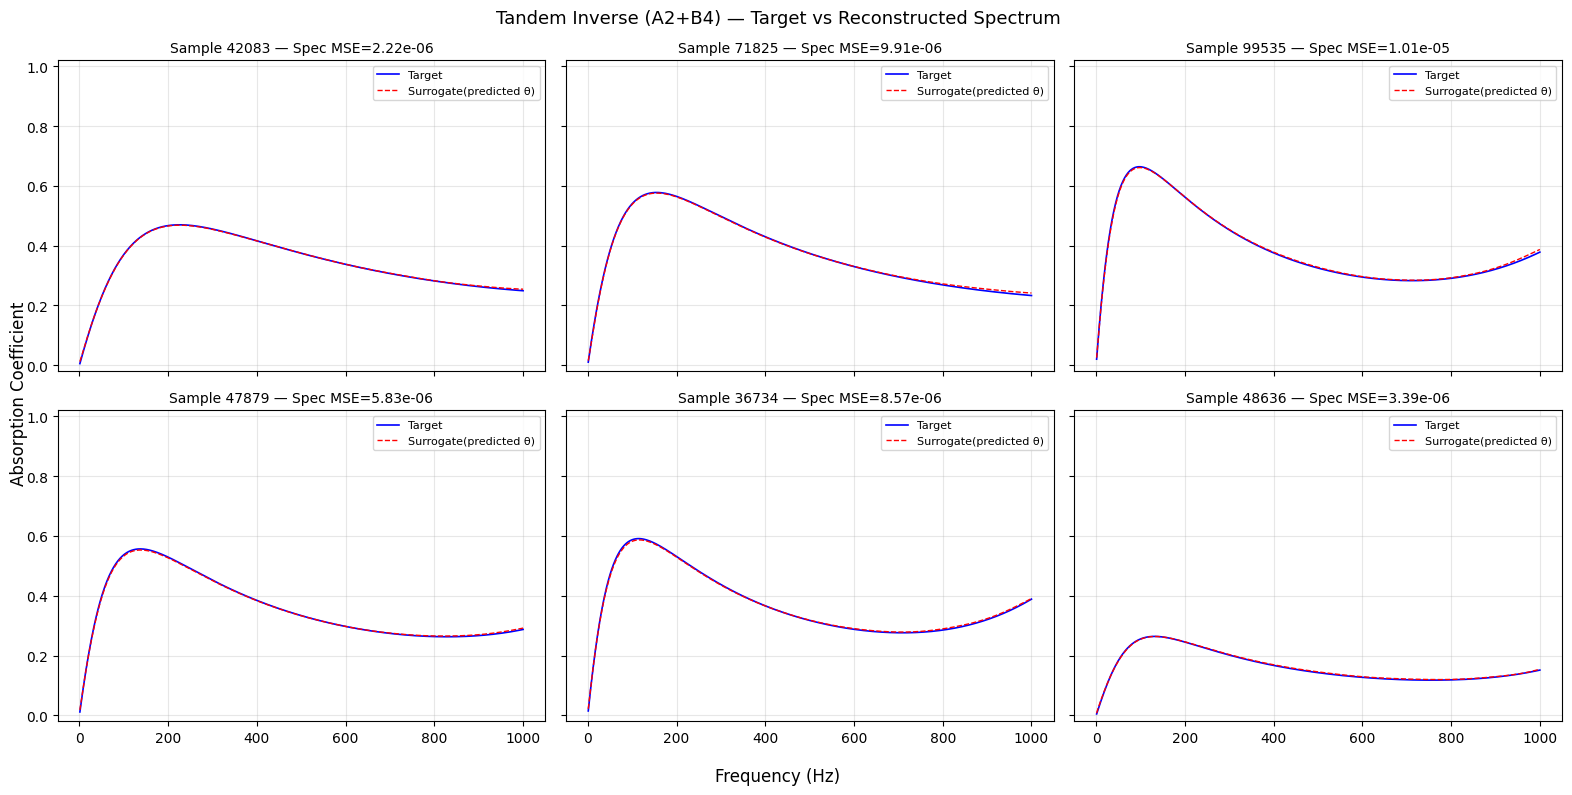

In [10]:
# ============================================================
# Cell 10 — Overlay: 6 Random Spectra (Target vs Surrogate Reconstruction)
# ============================================================
np.random.seed(123)
sample_idx = np.random.choice(len(target_spec), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, idx in zip(axes.flat, sample_idx):
    ax.plot(frequencies, target_spec[idx], 'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, recon_spec[idx],  'r--', lw=1.0, label='Surrogate(predicted θ)')
    mse_i = np.mean((target_spec[idx] - recon_spec[idx])**2)
    ax.set_title(f'Sample {idx} — Spec MSE={mse_i:.2e}', fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('Tandem Inverse (A2+B4) — Target vs Reconstructed Spectrum', fontsize=13)
plt.tight_layout()
plt.show()

## Validation Against Real TMM

The **gold standard** test: predicted parameters → real TMM physics engine → compare with target spectrum.

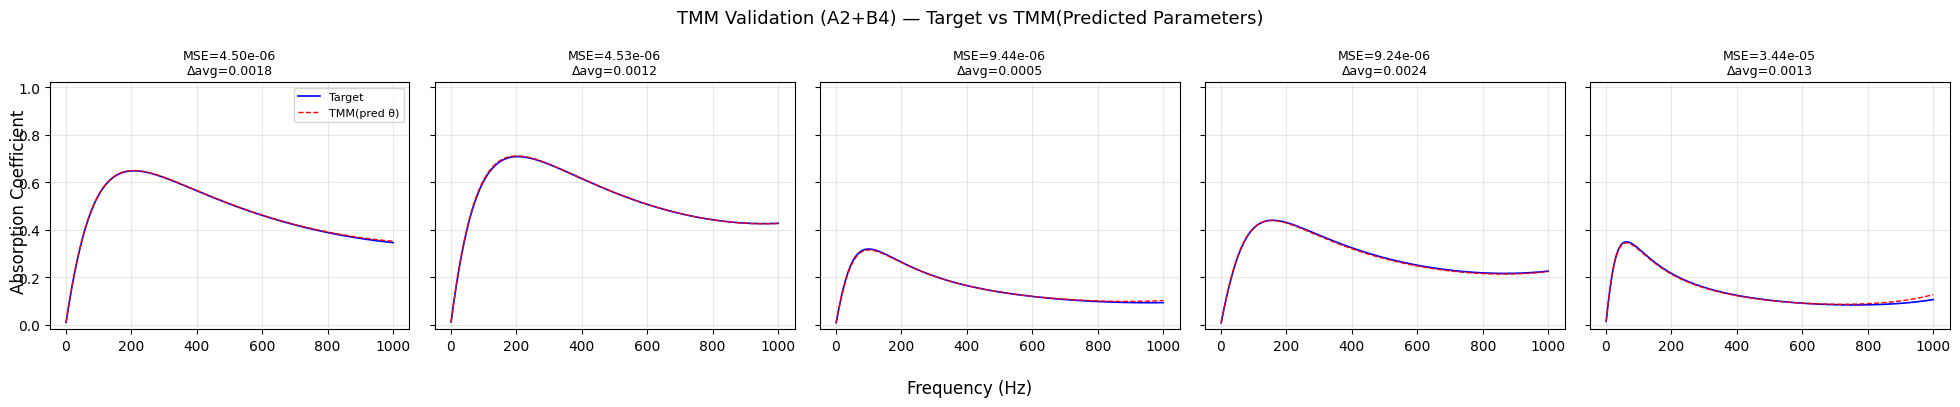


  TMM Validation Summary:
  -------------------------------------------------------
     Idx      Spec MSE   Δ Avg Abs  Target Avg     TMM Avg
  -------------------------------------------------------
   86155    4.5000e-06      0.0018      0.4763      0.4781
   29633    4.5308e-06      0.0012      0.5299      0.5312
   67710    9.4436e-06      0.0005      0.1612      0.1617
   62348    9.2382e-06      0.0024      0.2900      0.2876
   98787    3.4362e-05      0.0013      0.1426      0.1439
  -------------------------------------------------------
  Mean TMM MSE: 1.2415e-05


In [11]:
# ============================================================
# Cell 11 — TMM Validation (5 samples)
# ============================================================
NUM_TMM = 5
np.random.seed(99)
tmm_idx = np.random.choice(len(X_test), NUM_TMM, replace=False)

fig, axes = plt.subplots(1, NUM_TMM, figsize=(20, 4), sharex=True, sharey=True)
tmm_results = []

for ax, idx in zip(axes, tmm_idx):
    # Target spectrum (from dataset)
    target = Y_test[idx]

    # Inverse model prediction
    with torch.no_grad():
        spec_t = torch.tensor(target, dtype=torch.float32, device=device).unsqueeze(0)
        pred_n = inverse_model(spec_t).cpu().numpy().flatten()
    pred_raw = scaler_x.inverse_transform(pred_n.reshape(1, -1)).flatten()

    # Clip to valid ranges
    pred_raw_clipped = validate_and_clip_parameters(pred_raw.reshape(1, -1)).flatten()

    # Build TMM parameter dict
    param_dict = {
        'rho': float(pred_raw_clipped[16]),
        'eta': float(pred_raw_clipped[17]),
        'E':   float(pred_raw_clipped[18]),
        'nu':  float(pred_raw_clipped[19]),
        'W':   2000.0,
        'd':   [float(pred_raw_clipped[i]) for i in range(10)],
        'm':   {2: float(pred_raw_clipped[10]), 3: float(pred_raw_clipped[11]),
                5: float(pred_raw_clipped[12]), 6: float(pred_raw_clipped[13]),
                8: float(pred_raw_clipped[14]), 9: float(pred_raw_clipped[15])}
    }
    _, alpha_tmm, _, _ = calculate_acoustic_properties(param_dict)

    # Metrics
    mse_tmm  = np.mean((alpha_tmm - target)**2)
    avg_err  = abs(alpha_tmm.mean() - target.mean())
    tmm_results.append({'idx': idx, 'mse': mse_tmm, 'avg_err': avg_err,
                        'target_avg': target.mean(), 'tmm_avg': alpha_tmm.mean()})

    ax.plot(frequencies, target,    'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, alpha_tmm, 'r--', lw=1.0, label='TMM(pred θ)')
    ax.set_title(f'MSE={mse_tmm:.2e}\nΔavg={avg_err:.4f}', fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    if idx == tmm_idx[0]:
        ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('TMM Validation (A2+B4) — Target vs TMM(Predicted Parameters)', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print('\n  TMM Validation Summary:')
print('  ' + '-'*55)
print(f'  {"Idx":>6}  {"Spec MSE":>12}  {"Δ Avg Abs":>10}  {"Target Avg":>10}  {"TMM Avg":>10}')
print('  ' + '-'*55)
for r in tmm_results:
    print(f'  {r["idx"]:6d}  {r["mse"]:12.4e}  {r["avg_err"]:10.4f}  {r["target_avg"]:10.4f}  {r["tmm_avg"]:10.4f}')
print('  ' + '-'*55)
mean_tmm_mse = np.mean([r['mse'] for r in tmm_results])
print(f'  Mean TMM MSE: {mean_tmm_mse:.4e}')

## Error Distribution

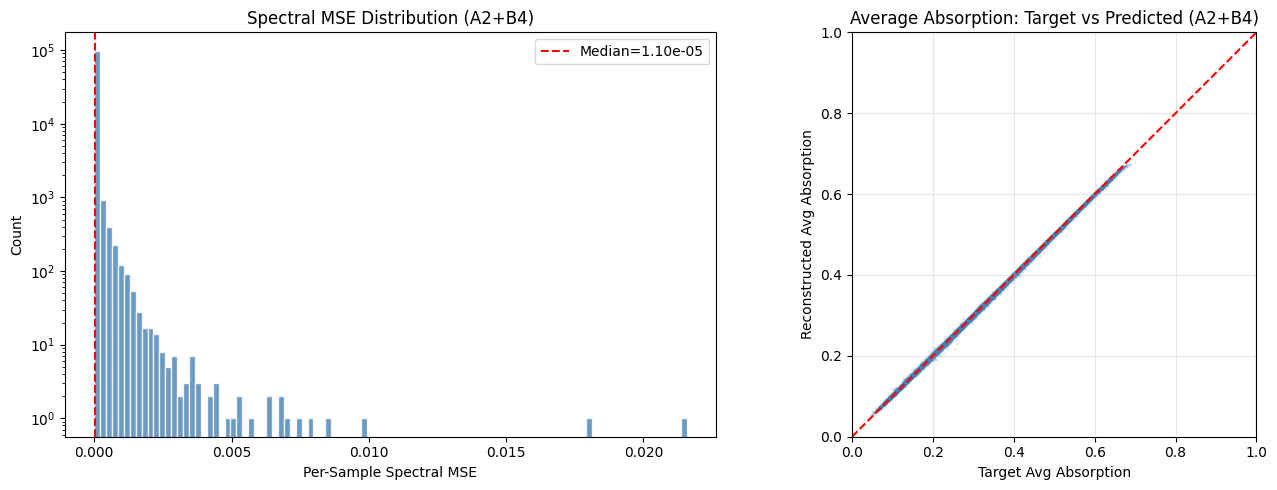

  50th percentile spectral MSE: 1.10e-05
  90th percentile spectral MSE: 4.30e-05
  95th percentile spectral MSE: 7.88e-05
  99th percentile spectral MSE: 4.41e-04


In [12]:
# ============================================================
# Cell 12 — Error Distribution
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Spectral MSE distribution
ax1.hist(spec_mse_per_sample, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.median(spec_mse_per_sample), color='red', ls='--',
            label=f'Median={np.median(spec_mse_per_sample):.2e}')
ax1.set_xlabel('Per-Sample Spectral MSE')
ax1.set_ylabel('Count'); ax1.set_yscale('log')
ax1.set_title('Spectral MSE Distribution (A2+B4)')
ax1.legend()

# Average absorption scatter
ax2.scatter(avg_target, avg_recon, s=1, alpha=0.1, c='steelblue')
ax2.plot([0, 1], [0, 1], 'r--', lw=1.5)
ax2.set_xlabel('Target Avg Absorption')
ax2.set_ylabel('Reconstructed Avg Absorption')
ax2.set_title('Average Absorption: Target vs Predicted (A2+B4)')
ax2.set_aspect('equal'); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for p in [50, 90, 95, 99]:
    print(f'  {p}th percentile spectral MSE: {np.percentile(spec_mse_per_sample, p):.2e}')

## Save Model

In [13]:
# ============================================================
# Cell 13 — Save
# ============================================================
torch.save({
    'model_state_dict': inverse_model.state_dict(),
    'architecture': {
        'embed_dim': HIDDEN_DIM,
        'num_params': NUM_PARAMS,
    },
    'train_loss': train_losses,
    'val_loss': val_losses,
    'best_val_loss': best_val,
    'surrogate_path': SURROGATE_PATH,
    'lambda_param': LAMBDA_PARAM,
}, INVERSE_PATH)

with open(INV_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler_x, f)

print(f'✓ Inverse model saved → {INVERSE_PATH}')
print(f'✓ Scaler saved → {INV_SCALER_PATH}')
print(f'  File size: {os.path.getsize(INVERSE_PATH)/1e6:.1f} MB')

✓ Inverse model saved → ../models\inverse_tandem_a2.pth
✓ Scaler saved → ../models\inverse_tandem_a2_scaler.pkl
  File size: 1.1 MB


---

## Summary

| Metric | Value |
|--------|-------|
| Forward surrogate | A2 CNN (frozen) |
| Inverse architecture | 1D-CNN encoder + MLP decoder |
| Training samples | 800,000 |
| Loss | Spectral MSE (through surrogate) + 0.1 × Parameter MSE |
| Best val loss | *(see above)* |
| Test spectral MSE | *(see above)* |
| TMM validation MSE | *(see above)* |

**Saved artefacts:**
- `models/inverse_tandem_a2.pth`
- `models/inverse_tandem_a2_scaler.pkl`

**Key advantage**: Single forward pass → fastest inference of all inverse methods.

**Limitation**: Deterministic — produces only one solution per target (no multi-modality).